# ISM — segmentation of physically touching soybean seeds (author-code reproduction)

**Paper:** *Image segmentation method for physically touching soybean seeds*, Software Impacts 18:100591 (2023), DOI [10.1016/j.simpa.2023.100591](https://doi.org/10.1016/j.simpa.2023.100591).
**Author code:** [`Great-Devil-1024/An-image-segmentation-method-for-the-physical-touching-soybean-seeds`](https://github.com/Great-Devil-1024/An-image-segmentation-method-for-the-physical-touching-soybean-seeds) @ commit `d4a2377ce61243f28af69161bfd507b3a3adfde2` (MIT license; identical file blob SHAs as the journal mirror [`SoftwareImpacts/SIMPAC-2023-375`](https://github.com/SoftwareImpacts/SIMPAC-2023-375)).

**Scope (one minimal example):** run the authors' own C++/OpenCV ISM pipeline — MSRCR contrast enhancement → Otsu-AT binarization → minimum-bounding-rectangle location → 13×13-kernel morphological breaking of touches → crop + resize to 227×227 — on the **two 3072×2048 touching-seed test images bundled in the repository's `src/`**, and inspect the produced individual seed images. This is a demonstration of the method's pipeline, not a verification of the paper's reported >98% dataset-level accuracy.

**Execution status:** CPU-only classical image processing (no trained model, no GPU needed). Executed end-to-end on a fresh Google Colab CPU runtime.

**AI-assisted adaptations (no algorithm changes; see the marked cell):** a small OpenCV-4 compatibility shim, rewriting two hardcoded local paths, and creating the author's debug output directory. All scientific code is the authors' own, compiled unmodified.

**日本語:** 大豆種子が物理的に接触している画像から個体（227×227 px）を切り出す著者実装（C++/OpenCV）を、著者コードそのままで Colab CPU 上で実行する最小デモです。手法：MSRCR コントラスト強調 → 大津の二値化 → 最小外接矩形による位置特定 → 13×13 カーネルのモルフォロジー処理による接触の分離 → 切り出しとリサイズ。

**References:** paper DOI above; code repository @ pinned commit; input images `src/Image_20220426214755980.bmp`, `src/Image_20220430064718171.bmp` from the same commit; dataset (ISM output, not used here): Mendeley Data `10.17632/v6vzvfszj6.6`.

## 1. Runtime selection and Run all

ISM is a classical image-processing pipeline (Retinex filtering, Otsu thresholding, contour/morphology ops on a 3072×2048 image) — **select Runtime type → CPU**; a GPU is unnecessary. Press *Runtime → Run all*.

Expected on a standard Colab CPU runtime: ~2–5 min for `apt` installing OpenCV dev headers, ~1–2 min to compile, and roughly half a minute of processing for the two test images; downloads ≈ 38 MB of test images plus apt packages. All data stays in the Colab VM (`/content`); nothing is read from Drive or the host.

**Limitations:** the two bundled images are the only inputs used; the paper's accuracy/throughput figures (Jetson TX2, ~100 ms/seed) are measured on different hardware and a different protocol and are not reproduced here.

**日本語:** 古典的な画像処理のみのため **CPU ランタイムで実行**します。セットアップ数分＋処理数十秒の見込みです。入力はリポジトリ同梱の2枚のみで、Drive やホストにはアクセスしません。

### Code — install the OpenCV C++ development environment

The author's code is C++ against OpenCV 3.4.8; we compile it with the distribution OpenCV (4.x) plus a tiny compatibility shim (next sections). This cell checks for `g++` and `pkg-config opencv4` and installs `libopencv-dev` via apt if missing, then prints the versions actually used.
Expected result: g++ ≥ 11 and an OpenCV 4.x version string. *(日本語: C++ コンパイル用の OpenCV 開発パッケージを導入し、バージョンを表示します。)*

In [ ]:
!command -v g++ && g++ --version | head -1
!pkg-config --modversion opencv4 2>/dev/null || (apt-get -qq update && apt-get -q install -y libopencv-dev pkg-config && pkg-config --modversion opencv4)
!pkg-config --modversion opencv4

/usr/bin/g++
g++ (Ubuntu 13.3.0-6ubuntu2~24.04.1) 13.3.0


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists...


Building dependency tree...


Reading state information...


The following additional packages will be installed:
  at-spi2-common at-spi2-core gsettings-desktop-schemas
  gstreamer1.0-plugins-base libatk-bridge2.0-0t64 libatk1.0-0t64
  libatspi2.0-0t64 libavcodec-dev libavformat-dev libavutil-dev libcdparanoia0
  libcharls2 libdc1394-dev libdouble-conversion3 libevdev2 libexif-dev
  libexif-doc libexif12 libgdcm-dev libgdcm3.0t64 libgl2ps1.4 libglew2.2
  libgphoto2-6t64 libgphoto2-dev libgphoto2-l10n libgphoto2-port12t64
  libgstreamer-plugins-base1.0-0 libgtk-3-0t64 libgtk-3-bin libgtk-3-common
  libgudev-1.0-0 libimath-3-1-29t64 libimath-dev libinput-bin libinput10
  libmd4c0 libmtdev1t64 libopencv-calib3d-dev libopencv-calib3d406t64
  libopencv-contrib-dev libopencv-contrib406t64 libopencv-core-dev
  libopencv-core406t64 libopencv-dnn-dev libopencv-dnn406t64
  libopencv-features2d-dev libopencv-features2d406t64 libopencv-flann-dev
  libopencv-flann406t64 libopencv-highgui-dev libopencv-highgui406t64
  libopencv-imgcodecs-dev libopencv-imgcod

...

Processing triggers for libgdk-pixbuf-2.0-0:amd64 (2.42.10+dfsg-3ubuntu3.3) ...
Processing triggers for libc-bin (2.39-0ubuntu8.9) ...


/sbin/ldconfig.real: /usr/local/lib/libtbbmalloc.so.2 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbb.so.12 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbbind_2_5.so.3 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbbind.so.3 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libur_adapter_level_zero_v2.so.0 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbbind_2_0.so.3 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtcm_debug.so.1 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbmalloc_proxy.so.2 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libhwloc.so.15 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libur_adapter_opencl.so.0 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtcm.so.1 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libur_loader.so.0 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libur_adapt

Setting up libgtk-3-bin (3.24.41-4ubuntu1.3) ...
Setting up qt5-gtk-platformtheme:amd64 (5.15.13+dfsg-1ubuntu1) ...


4.6.0


4.6.0


## 2. Acquire the pinned author code and test images

The repository is cloned **inside Colab** as a partial, shallow clone of the exact pinned commit `d4a2377ce61243f28af69161bfd507b3a3adfde2` (no other branch/revision, LFS smudging disabled). The checkout commit is asserted, and the bundled inputs are listed.
Expected result: `CLONED d4a2377...`, two `.bmp` files (~18.9 MB each) and a 48-byte `path.txt` under `src/`. *(日本語: 著者リポジトリを指定コミットで部分的にクローンし、入力画像を確認します。)*

In [ ]:
import subprocess
REPO = "https://github.com/Great-Devil-1024/An-image-segmentation-method-for-the-physical-touching-soybean-seeds"
SHA  = "d4a2377ce61243f28af69161bfd507b3a3adfde2"  # pinned commit (blob-identical to SoftwareImpacts/SIMPAC-2023-375)

cmd = f'''
set -e
export GIT_LFS_SKIP_SMUDGE=1
rm -rf /content/ism_repo
git init -q /content/ism_repo
cd /content/ism_repo
git remote add origin {REPO}
git config extensions.partialclone origin
git fetch -q --depth 1 --filter=blob:none origin {SHA}
git checkout -q FETCH_HEAD
echo CLONED $(git rev-parse HEAD)
ls -la src/ && wc -c path.txt
'''
r = subprocess.run(["bash", "-lc", cmd], capture_output=True, text=True)
print(r.stdout, r.stderr[-1000:])
assert r.returncode == 0 and f"CLONED {SHA}" in r.stdout, "pinned clone failed"


CLONED d4a2377ce61243f28af69161bfd507b3a3adfde2
total 36880
drwxr-xr-x 2 root root     4096 Oct  8 23:36 .
drwxr-xr-x 5 root root     4096 Oct  8 23:36 ..
-rw-r--r-- 1 root root 18874422 Oct  8 23:36 Image_20220426214755980.bmp
-rw-r--r-- 1 root root 18874422 Oct  8 23:36 Image_20220430064718171.bmp
48 path.txt
 


### Code — verify and preview the two touching-seed inputs

Reads `path.txt` (the image-name list consumed by `main.cpp`; the author hard-codes `Line_number = 2`), validates both BMPs as 3072×2048 8-bit 3-channel images, and displays them. This is the human-readable input preview required before the analysis. Expected: exactly two names, matching the two files in `src/`. *(日本語: path.txt の内容と入力画像 2 枚のサイズを検証し、プレビュー表示します。)*

path.txt: ['Image_20220426214755980', 'Image_20220430064718171']
Image_20220426214755980 (2048, 3072, 3) uint8


Image_20220430064718171 (2048, 3072, 3) uint8


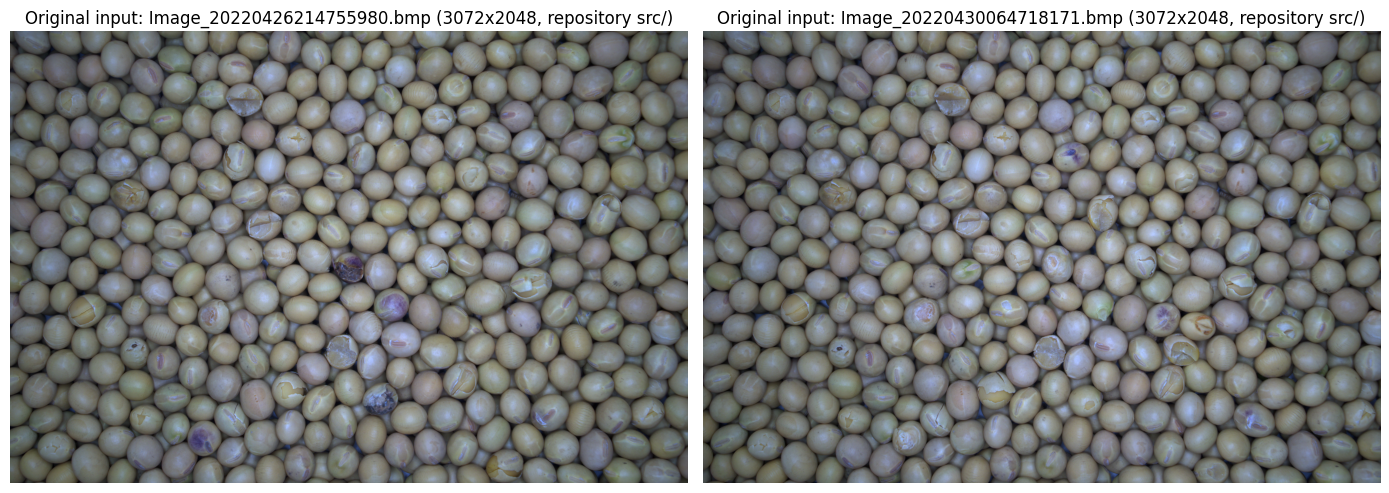

In [ ]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

root = Path('/content/ism_repo/src')
names = [l.strip() for l in open('/content/ism_repo/path.txt') if l.strip()]
assert len(names) == 2, f"main.cpp expects Line_number=2, path.txt has {len(names)} lines: {names}"
print("path.txt:", names)

imgs = {}
for n in names:
    im = cv2.imread(str(root / f"{n}.bmp"), cv2.IMREAD_COLOR)
    assert im is not None and im.shape == (2048, 3072, 3), f"{n}: unexpected content {None if im is None else im.shape}"
    imgs[n] = im
    print(n, im.shape, im.dtype)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, n in zip(axes, names):
    ax.imshow(cv2.cvtColor(imgs[n], cv2.COLOR_BGR2RGB))
    ax.set_title(f"Original input: {n}.bmp (3072x2048, repository src/)")
    ax.axis("off")
plt.tight_layout(); plt.show()


## 3. Minimal compatibility adaptations (AI-authored glue — no algorithm changes)

Three documented, behavior-preserving adaptations are applied; **the scientific code is compiled unmodified**:

| # | Adaptation | Why | Effect on results |
|---|---|---|---|
| 1 | `compat.hpp` shim (prepended with `-include`): declares the legacy C-API headers used by the authors' `MSRCR_Function.h` (`IplImage`, `cvCreateImage`, `cvLog`, …) and maps the three OpenCV-3-era constant names used in the code (`CV_RETR_TREE`, `CV_CHAIN_APPROX_SIMPLE`, `CV_BGR2GRAY`) to their identical OpenCV 4 values. | Author code targets OpenCV 3.4.8; Colab apt provides OpenCV 4.x. | None — the macros only rename constants; the C API itself compiles and links against OpenCV 4. |
| 2 | `sed` of the two hard-coded author paths (`/home/lw/Desktop/Linux Version/…`) to `/content/ism_repo/…`. | Those absolute paths exist only on the authors' machine. | Path strings only. |
| 3 | `mkdir -p /opt/MVS/Data`. | `MSRCR_Function.h` contains a leftover **debug** round-trip (`imwrite`/`imread` of `/opt/MVS/Data/16.bmp`, a Hikvision MVS directory on the author's PC) that only computes a printed saturation diagnostic; it does not affect the enhanced image. We create the directory instead of editing the authors' debug code. | None on outputs; one extra debug `rate` line on stdout. |

Also preserved as-is: the authors' commented-out Watershed branch, and the fact that `morphologyEx(..., MORPH_RECT, …)` passes the *shape* constant `MORPH_RECT==0` as the *operation*, i.e. an **erosion** with the paper's 13×13 rectangular kernel.

**日本語:** 著者コードは無変更のまま、OpenCV 4 用の小さな互換ヘッダ・2 つのハードコードパスの書き換え・デバッグ出力先ディレクトリの作成のみ行います。13×13 モルフォロジー処理やコメントアウトされた Watershed 分岐など、著者の挙動はそのまま保たれます。

In [ ]:
import subprocess
from pathlib import Path

SRC = "An image segmentation method/Soybean_seed image processing/main.cpp"

shim = '''// AI-authored compatibility shim (see notebook section 3): legacy C-API
// declarations for the authors MSRCR_Function.h plus three constant-name
// mappings; macros are defined AFTER the legacy headers so their enum
// definitions are not rewritten. No algorithm change.
#include <opencv2/core/core_c.h>
#include <opencv2/imgproc/imgproc_c.h>
#define CV_RETR_TREE cv::RETR_TREE
#define CV_CHAIN_APPROX_SIMPLE cv::CHAIN_APPROX_SIMPLE
#define CV_BGR2GRAY cv::COLOR_BGR2GRAY
'''
Path('/content/ism_repo/compat.hpp').write_text(shim)
subprocess.run(["mkdir", "-p", "/opt/MVS/Data"], check=True)  # author debug-imwrite target (section 3)

sed = ("sed -i 's|/home/lw/Desktop/Linux Version/path.txt|/content/ism_repo/path.txt|; "
       "s|/home/lw/Desktop/Linux Version/src/|/content/ism_repo/src/|' '" + SRC + "'")
cmd = f'cd /content/ism_repo && {sed} && grep -n -e "image_names =" -e "root_img_path =" "{SRC}"'
r = subprocess.run(["bash", "-lc", cmd], capture_output=True, text=True)
print(r.stdout, r.stderr); assert r.returncode == 0

cmd = f'cd /content/ism_repo && g++ -O2 "{SRC}" -o /content/ism -include compat.hpp $(pkg-config --cflags --libs opencv4)'
r = subprocess.run(["bash", "-lc", cmd], capture_output=True, text=True)
print(r.stdout[-500:], r.stderr[-1500:])
assert Path('/content/ism').exists(), "compile failed"
print("COMPILE_OK: /content/ism built from unmodified author sources + shim")


17:string image_names = "/content/ism_repo/path.txt"; // this algorithm processes the images according to images' name in this file.
30:		string root_img_path = "/content/ism_repo/src/"; // the original images are saved in this file
 


 In file included from An image segmentation method/Soybean_seed image processing/External_matrix.h:2,
                 from An image segmentation method/Soybean_seed image processing/main.cpp:8:
An image segmentation method/Soybean_seed image processing/create_img.h: In function ‘std::string create_path(int, std::string, std::string, std::string)’:
An image segmentation method/Soybean_seed image processing/create_img.h:25:1: warning: control reaches end of non-void function [-Wreturn-type]
   25 | }
      | ^

COMPILE_OK: /content/ism built from unmodified author sources + shim


## 4. Run ISM on the two test images

Executes the compiled author binary exactly as `main.cpp` implements it: for each of the two `path.txt` names it runs MSRCR enhancement, Otsu binarization + contour location, and saves `MSRCR/MSRCR.bmp`, `Binary/Binary.bmp` and the `Individual_Seeds/*.bmp` 227×227 crops under each image's directory. The full stdout is kept in `/content/ism_run.log`; this cell prints the processing markers, the author's debug `rate` line, and the program's own timing lines. *(日本語: コンパイル済みの著者バイナリを2枚の画像に対して実行し、処理マーカーと計測時間を表示します。)*

In [ ]:
import subprocess, time

t0 = time.perf_counter()
r = subprocess.run(["bash", "-lc", "cd /content && ./ism"], capture_output=True, text=True, timeout=1800)
wall = time.perf_counter() - t0
Path('/content/ism_run.log').write_text(r.stdout)

lines = r.stdout.splitlines()
print("markers :", [l for l in lines if "Processing" in l])
print("debug rate lines (authors' MSRCR diagnostic, section 3):", [l for l in lines if l.strip().replace('.','',1).isdigit()])
print("program timing:", [l for l in lines if "Time" in l or "Avarage" in l])
print(f"wall time on this runtime: {wall:.1f} s")
assert r.returncode == 0, f"ism exited {r.returncode}"


markers : ['Image_20220426214755980 Processing.....', 'Image_20220426214755980 Processing completed.', 'Image_20220430064718171 Processing.....', 'Image_20220430064718171 Processing completed.']
debug rate lines (authors' MSRCR diagnostic, section 3): ['0.774628', '0.783016']
program timing: ['Total Runing Time: 16.7789 s', 'The Avarage Time for Segmentation a Individual Soybean Seeds: 0.0294885 s']
wall time on this runtime: 17.3 s


### Code — intermediate results: MSRCR enhancement and Otsu binary mask

Displays the two intermediates the pipeline writes per image: the MSRCR-enhanced image (sigmas 30/150/300, equal weights, per `MSRetinexCR.h`) and the Otsu-thresholded binary mask used for locating seeds. *(日本語: パイプラインの中間生成物である MSRCR 強調画像と二値画像を表示します。)*

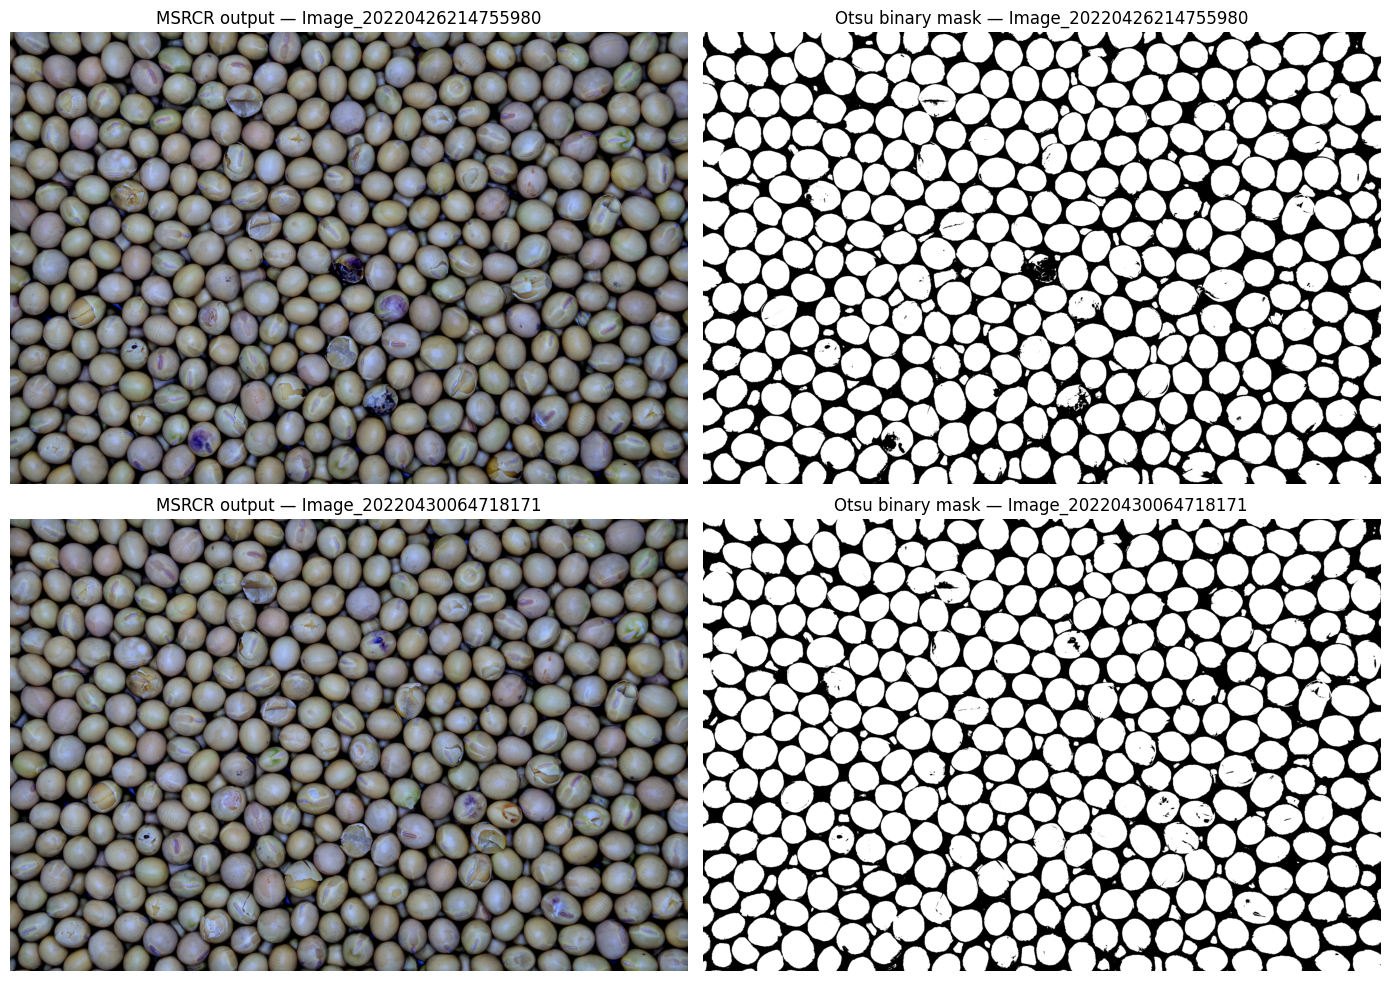

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for row, n in enumerate(names):
    msrcr = cv2.imread(str(root / n / "MSRCR" / "MSRCR.bmp"))
    binary = cv2.imread(str(root / n / "Binary" / "Binary.bmp"), cv2.IMREAD_GRAYSCALE)
    assert msrcr is not None and binary is not None, n
    axes[row, 0].imshow(cv2.cvtColor(msrcr, cv2.COLOR_BGR2RGB))
    axes[row, 0].set_title(f"MSRCR output — {n}"); axes[row, 0].axis("off")
    axes[row, 1].imshow(binary, cmap="gray")
    axes[row, 1].set_title(f"Otsu binary mask — {n}"); axes[row, 1].axis("off")
plt.tight_layout(); plt.show()


### Code — individual seed crops (227×227) produced by ISM

Shows the first 12 `Individual_Seeds/*.bmp` crops per test image (numbering runs continuously across the two images, as implemented by the authors' global `count_seeds`). Each crop is verified to be 227×227 before display. *(日本語: 切り出された 227×227 個体画像を各画像ごとに表示します（番号は著者実装どおり連続）。)*

Image_20220426214755980: 285 individual seed crops (227x227)


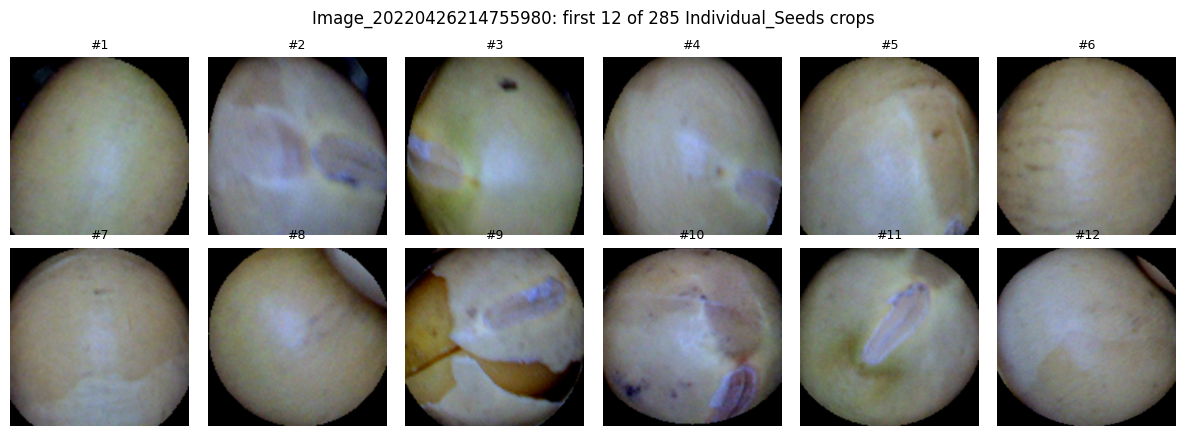

Image_20220430064718171: 283 individual seed crops (227x227)


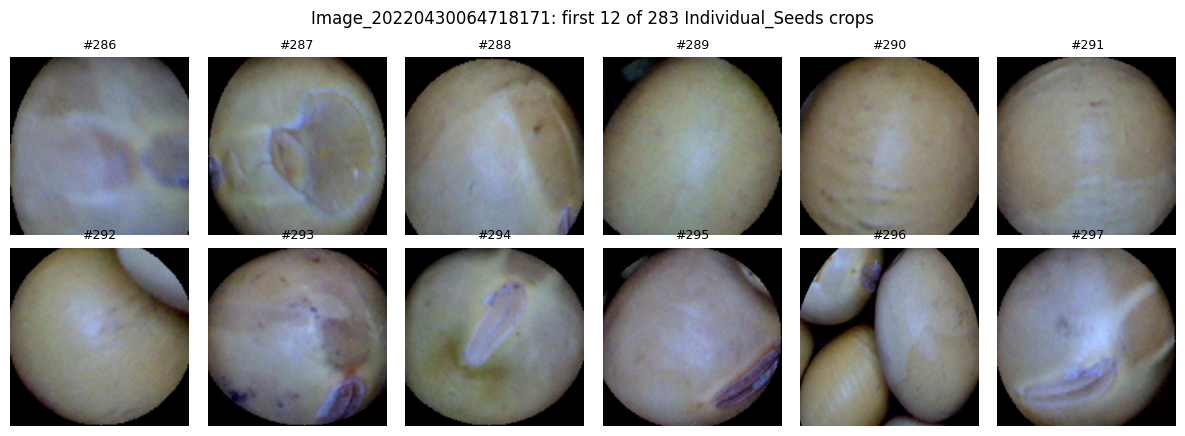

In [ ]:
import glob, os, math
import matplotlib.pyplot as plt

for n in names:
    seeds = sorted(glob.glob(str(root / n / "Individual_Seeds" / "*.bmp")),
                   key=lambda p: int(os.path.basename(p)[:-4]))
    shapes = {cv2.imread(s).shape for s in seeds}
    assert shapes == {(227, 227, 3)}, f"{n}: unexpected crop shapes {shapes}"
    print(f"{n}: {len(seeds)} individual seed crops (227x227)")

    sel = seeds[:12]
    fig, axes = plt.subplots(2, 6, figsize=(12, 4.4))
    for ax, s in zip(axes.ravel(), sel):
        ax.imshow(cv2.cvtColor(cv2.imread(s), cv2.COLOR_BGR2RGB))
        ax.set_title(f"#{os.path.basename(s)[:-4]}", fontsize=9); ax.axis("off")
    fig.suptitle(f"{n}: first 12 of {len(seeds)} Individual_Seeds crops")
    plt.tight_layout(); plt.show()


### Code — input vs. pipeline mask overlay (additional visualization)

An AI-created diagnostic overlay (not an author figure): the pipeline's own `Binary.bmp` contours are drawn on the original input to show which regions ISM located as seeds. Saved/kept only as notebook output. *(日本語: 著者図ではなく本ノートブック用の可視化です。パイプラインが生成した二値マスクの輪郭を元画像に重ねて表示します。)*

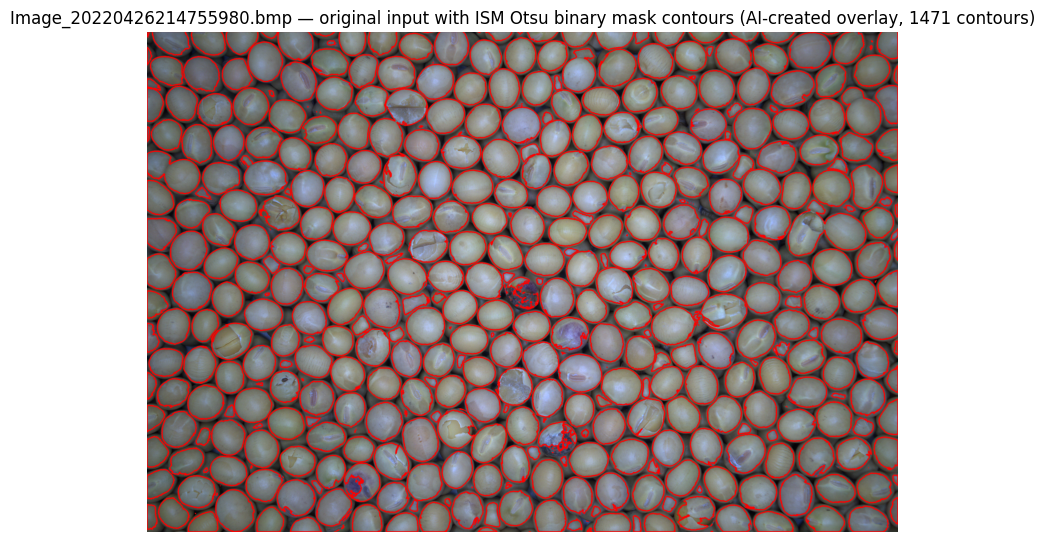

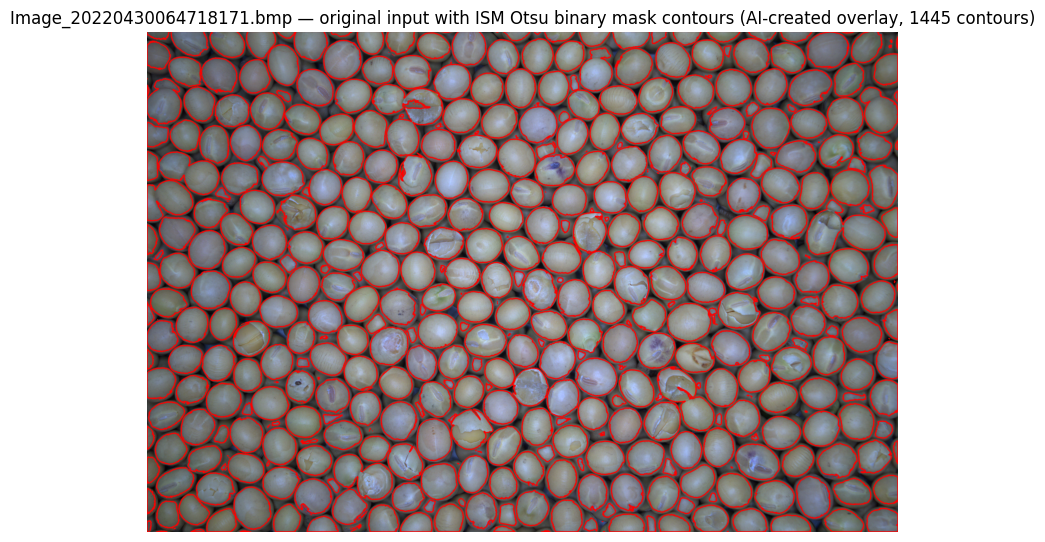

In [ ]:
import cv2
import matplotlib.pyplot as plt

for n in names:
    binary = cv2.imread(str(root / n / "Binary" / "Binary.bmp"), cv2.IMREAD_GRAYSCALE)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    overlay = imgs[n].copy()
    cv2.drawContours(overlay, contours, -1, (0, 0, 255), 4)
    scale = 1536 / overlay.shape[1]
    overlay = cv2.resize(overlay, (1536, int(overlay.shape[0] * scale)))
    plt.figure(figsize=(12, 6.5))
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title(f"{n}.bmp — original input with ISM Otsu binary mask contours (AI-created overlay, {len(contours)} contours)")
    plt.axis("off"); plt.show()


### Code — results table and CSV export

Summarizes the run as a small table: seed count per image, crop-shape check, and the measured wall time; exported to `/content/ism_seed_counts.csv`. The author counter runs continuously (image 2 continues after image 1). *(日本語: 個体数・切り出しサイズ・計測時間を表にまとめ、CSV に出力します。)*

In [ ]:
import glob, os, cv2, pandas as pd

rows = []
for n in names:
    seeds = sorted(glob.glob(str(root / n / "Individual_Seeds" / "*.bmp")),
                   key=lambda p: int(os.path.basename(p)[:-4]))
    shapes = {cv2.imread(s).shape for s in seeds}
    rows.append({"image": n, "individual_seeds_227x227": len(seeds),
                 "all_crops_227x227x3": str(shapes == {(227, 227, 3)})})
df = pd.DataFrame(rows)
display(df)
df.to_csv("/content/ism_seed_counts.csv", index=False)
print("saved /content/ism_seed_counts.csv")


,image,individual_seeds_227x227,all_crops_227x227x3
0,Image_20220426214755980,285,True
1,Image_20220430064718171,283,True


saved /content/ism_seed_counts.csv


## 5. Interpretation, validation record and limitations

**What this notebook verifies:** the authors' ISM implementation, compiled from the pinned commit and run unmodified (except the documented glue in section 3), segments the two bundled touching-seed images into individual 227×227 seed crops with per-image MSRCR/Binary intermediates — the pipeline described in the paper (MSRCR → Otsu-AT → MBR → 13×13 morphological touch breaking → 227×227 crops).

**What it does not verify:** the paper's ">98% overall segmentation accuracy" (protocol, test set and ground truth are not reported in the available text) and the "~100 ms/seed on Jetson TX2" figure (different hardware; here we report the measured wall time of this run). Seed counts here are pipeline outputs, not ground truth. Free-tier Colab time and availability may differ.

**Source provenance:** code and inputs from `Great-Devil-1024/An-image-segmentation-method-for-the-physical-touching-soybean-seeds` @ `d4a2377ce61243f28af69161bfd507b3a3adfde2` (MIT; blob-identical to `SoftwareImpacts/SIMPAC-2023-375`); paper: Software Impacts 18:100591 (2023), DOI 10.1016/j.simpa.2023.100591. Investigation guidance (PhenoPaper) was used as prior research leads only; all parameters above were verified against the pinned code.

**日本語:** 本ノートブックは、著者の ISM 実装をピン留めしたコミットからそのままコンパイル・実行し、同梱の2枚の画像から 227×227 の個体画像を切り出せることを示す最小デモです。論文の精度（>98%）や Jetson TX2 の処理時間（約100 ms/種子）の検証は含みません。個体数はパイプラインの出力であり正解ラベルではありません。